# KNN and Distance Metrics

Classifies patients as normal or abnormal from six spinal measurements, then tests how the choice of distance metric changes the result. Across metrics the test error runs from 0.06 with Minkowski at log10(p) = 0.6 to 0.17 with Mahalanobis, on an otherwise identical model.

**Data:** Vertebral Column; 310 patients, 6 biomechanical features, 2 classes; UCI Machine Learning Repository
https://archive.ics.uci.edu/dataset/212/vertebral+column

## Models
| Model | Section | What it does |
|---|---|---|
| KNN, Euclidean | KNN with Euclidean distance | Majority vote; k swept from 208 down to 1 |
| KNN, Euclidean on subsets | Learning curve | Best k per training size as the set grows from 10 to 210 rows |
| KNN, Manhattan (Minkowski p = 1) | Alternative distance metrics | k from 1, 6, 11 up to 196 |
| KNN, Minkowski | Alternative distance metrics | log10(p) from 0.1 to 1, at the k found for Manhattan |
| KNN, Chebyshev | Alternative distance metrics | Minkowski as p goes to infinity |
| KNN, Mahalanobis | Alternative distance metrics | Training covariance inverted and passed to the metric; brute-force search |
| KNN, distance-weighted | Distance-weighted voting | Votes weighted by inverse distance; Euclidean, Manhattan and Chebyshev |

## Contents
| Section | What it covers |
|---|---|
| Data preparation | Original NO and AB labels mapped to a binary normal/abnormal target |
| Exploratory plots | Pairwise scatterplots and per-feature boxplots split by class |
| Train and test split | First 70 normal and first 140 abnormal rows held out as training data |
| KNN with Euclidean distance | k swept from 208 down to 1; confusion matrix, TPR, TNR, precision and F1 at k* = 4 |
| Learning curve | Lowest achievable test error as the training set grows from 10 to 210 rows |
| Alternative distance metrics | Manhattan, Minkowski across log10(p), Chebyshev and Mahalanobis |
| Distance-weighted voting | Votes weighted by inverse distance for the Euclidean, Manhattan and Chebyshev fits |

### (a) Download Data
Download the Vertebral Column Data Set from: https://archive.ics.uci.edu/ml/datasets/Vertebral+Column.
### Class Label Mapping
| Original Label | Binary Class | Category |
|:---------------| :--- | :--- |
| **NO**         | 0 | Normal |
| **AB**         | 1 | Abnormal |
| **DH**         | 1 | Disk Hernia (mapped to Abnormal) |
| **SL**         | 1 | Spondylolisthesis (mapped to Abnormal) |


Package imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as metrics


from sklearn.neighbors import KNeighborsClassifier



Get the Vertebral Column Data Set

In [6]:
df = pd.read_csv('data/column_2C.dat', sep='\s+', header=None, names= ['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'grade_spondylolisthesis', 'class'])
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/dm/c8mhrzyd51v9mrbpyrljrctr0000gn/T/ipykernel_33921/3648361885.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('data/column_2C.dat', sep='\s+', header=None, names= ['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'grade_spondylolisthesis', 'class'])


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,grade_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,AB
1,39.06,10.06,25.02,29.00,114.41,4.56,AB
2,68.83,22.22,50.09,46.61,105.99,-3.53,AB
3,69.30,24.65,44.31,44.64,101.87,11.21,AB
4,49.71,9.65,28.32,40.06,108.17,7.92,AB


Label classes (Normal = 0, Abnormal = 1)

In [7]:
df['class'] = df['class'].map({'NO': 0, 'AB': 1})
print(df.shape)
df.head()

(310, 7)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,grade_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,1
1,39.06,10.06,25.02,29.00,114.41,4.56,1
2,68.83,22.22,50.09,46.61,105.99,-3.53,1
3,69.30,24.65,44.31,44.64,101.87,11.21,1
4,49.71,9.65,28.32,40.06,108.17,7.92,1


### (b) Pre-Processing and Exploratory Data Analysis

#### i. Scatterplots

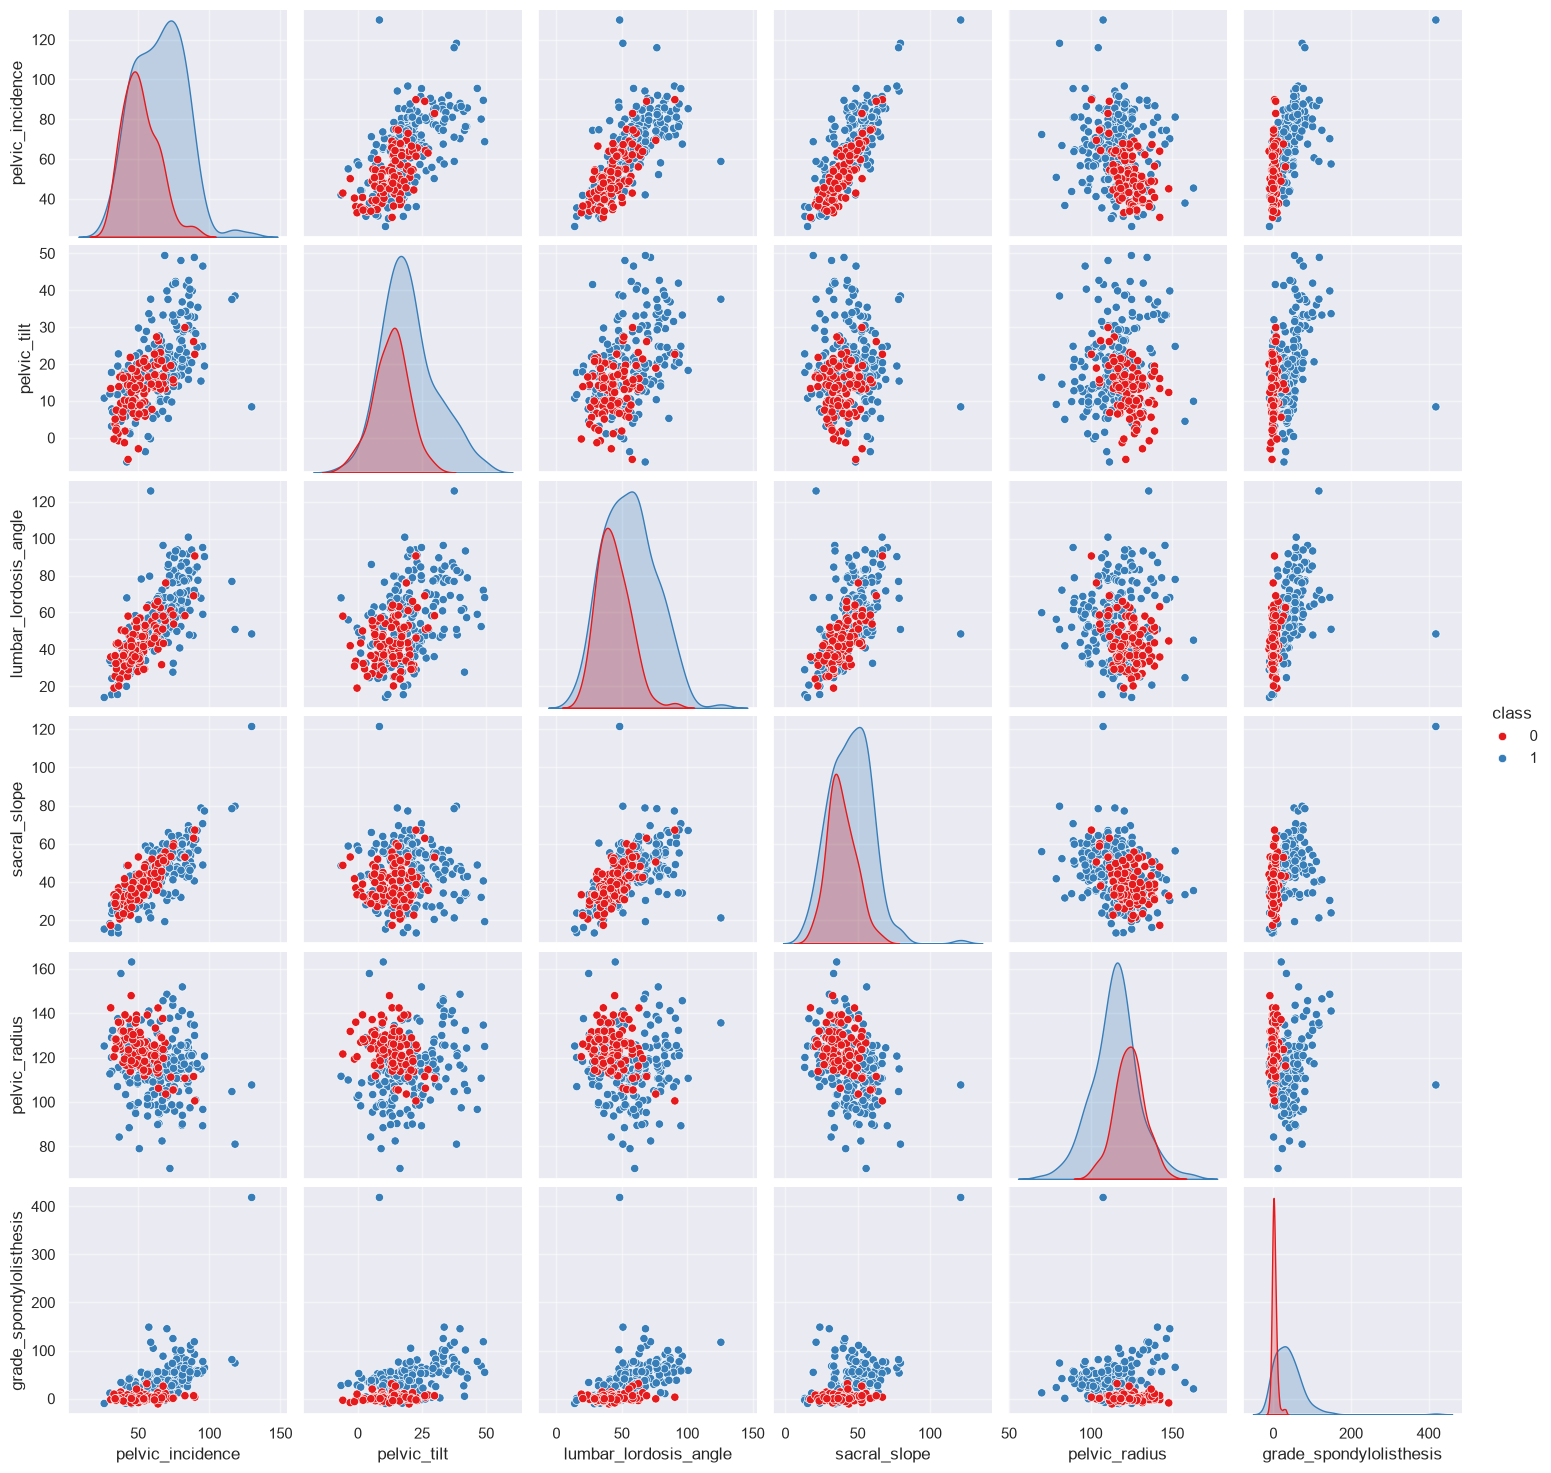

In [8]:
sns.set()
sns.pairplot(data = df, hue='class',palette='Set1')
plt.show()

#### ii. Boxplots

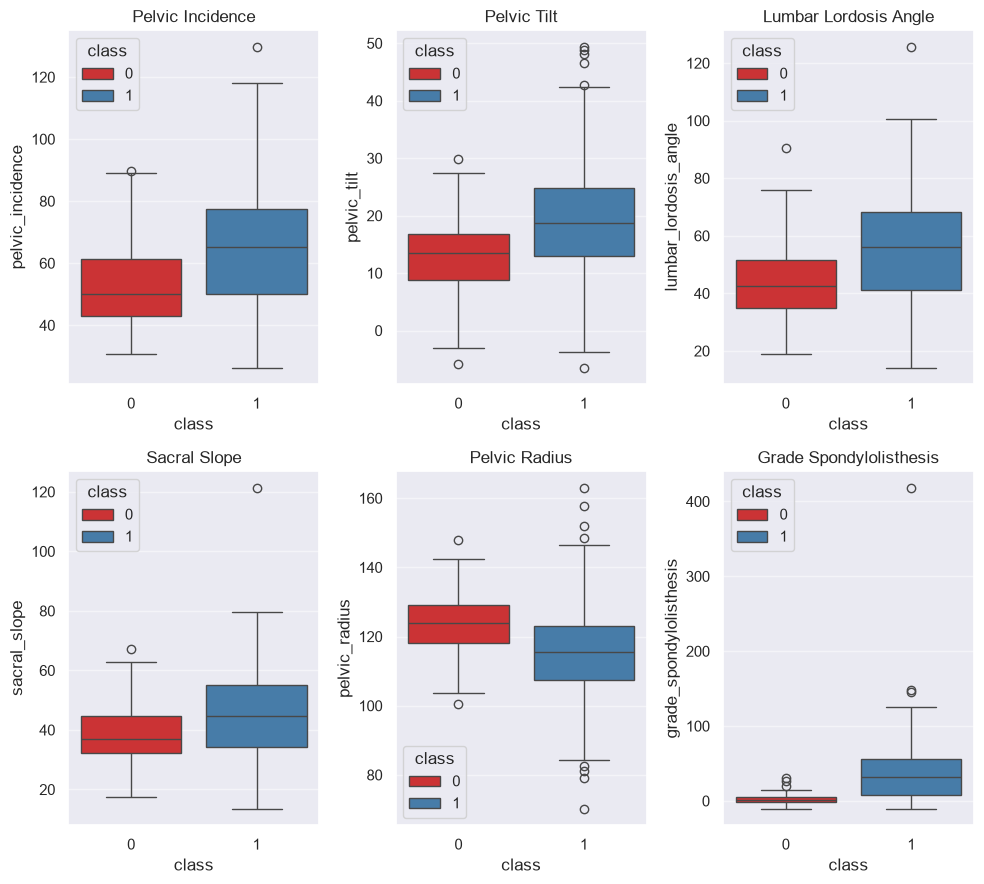

In [9]:
plt.figure(figsize=(10, 9))

plt.subplot(2, 3, 1)
sns.boxplot(x='class', y='pelvic_incidence', data=df, hue='class', palette='Set1')
plt.title('Pelvic Incidence')

plt.subplot(2, 3, 2)
sns.boxplot(x='class', y='pelvic_tilt', data=df, hue='class', palette='Set1')
plt.title('Pelvic Tilt')

plt.subplot(2, 3, 3)
sns.boxplot(x='class', y='lumbar_lordosis_angle', data=df, hue='class', palette='Set1')
plt.title('Lumbar Lordosis Angle')

plt.subplot(2, 3, 4)
sns.boxplot(x='class', y='sacral_slope', data=df, hue='class', palette='Set1')
plt.title('Sacral Slope')

plt.subplot(2, 3, 5)
sns.boxplot(x='class', y='pelvic_radius', data=df, hue='class', palette='Set1')
plt.title('Pelvic Radius')

plt.subplot(2, 3, 6)
sns.boxplot(x='class', y='grade_spondylolisthesis', data=df, hue='class', palette='Set1')
plt.title('Grade Spondylolisthesis')
plt.tight_layout()
plt.show()

#### iii. Split Data Set
Select the first 70 rows of Class 0 and the first 140 rows of Class 1 as the training set and the rest of the data as the test set.

In [10]:
class_0 =df[df['class']==0]
class_1 = df[df['class']==1]

train_df = pd.concat([class_0.iloc[:70], class_1.iloc[:140]])
train_df = train_df.reset_index(drop=True)
test_df = pd.concat([class_0.iloc[70:], class_1.iloc[140:]])
test_df = test_df.reset_index(drop=True)

print(train_df.shape,'\n')
print(test_df.shape)

X_test = test_df.drop(columns=['class'])
y_test = test_df['class']
y_train = train_df['class']
X_train = train_df.drop(columns=['class'])
print(X_train)

display(y_train.to_frame().head(), X_train.head())


(210, 7) 

(100, 7)
     pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
0               38.51        16.96                  35.11         21.54   
1               54.92        18.97                  51.60         35.95   
2               44.36         8.95                  46.90         35.42   
3               48.32        17.45                  48.00         30.87   
4               45.70        10.66                  42.58         35.04   
..                ...          ...                    ...           ...   
205             77.12        30.35                  77.48         46.77   
206             88.02        39.84                  81.77         48.18   
207             83.40        34.31                  78.42         49.09   
208             72.05        24.70                  79.87         47.35   
209             85.10        21.07                  91.73         64.03   

     pelvic_radius  grade_spondylolisthesis  
0           127.63               

,class
0,0
1,0
2,0
3,0
4,0


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,grade_spondylolisthesis
0,38.51,16.96,35.11,21.54,127.63,7.99
1,54.92,18.97,51.60,35.95,125.85,2.00
2,44.36,8.95,46.90,35.42,129.22,4.99
3,48.32,17.45,48.00,30.87,128.98,-0.91
4,45.70,10.66,42.58,35.04,130.18,-3.39


### (c) Classification using KNN on Vertebral Column Data Set

#### i. Euclidean Metric

In [11]:
def euclidian_knn(X_train, y_train, X_test, y_test, k):
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    train_err = 1 - knn.score(X_train, y_train)
    test_err = 1 - knn.score(X_test, y_test)
    return train_err, test_err


#### ii. Test Data:
Determines the optimal $k^*$ by testing the range $k \in \{208, 205, \dots, 7, 4, 1\}$. Select model with the $k$ that minimizes the test error and evaluate its performance using the following metrics: Confusion Matrix, True Positive Rate (TPR) and True Negative Rate (TNR), Precision & $F_1$-score.

Optimal k = 4 with Test Error = 0.06000000000000005


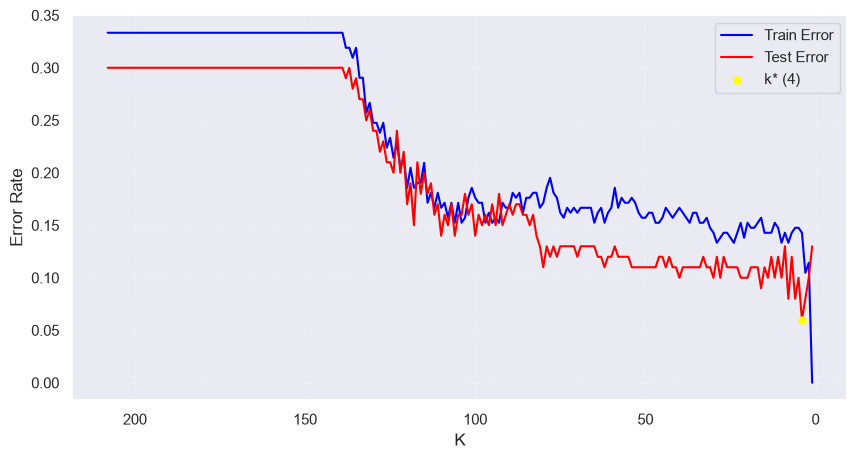

In [12]:
k_values = np.arange(208,0,-1)
train_errors = []
test_errors = []

for k in k_values:
    train_err, test_err = euclidian_knn(X_train, y_train, X_test, y_test, k)
    train_errors.append(train_err)
    test_errors.append(test_err)

# k* that minimizes the test error
k_star = k_values[np.argmin(test_errors)]
k_star_test_error = min(test_errors)
print(f'Optimal k = {k_star} with Test Error = {k_star_test_error}')

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_errors, label='Train Error',color='blue')
plt.plot(k_values, test_errors, label='Test Error',color='red')
plt.scatter(k_star, k_star_test_error, color='yellow', s=25, label=f'k* ({k_star})',zorder=5)
plt.gca().invert_xaxis()
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.25)
plt.show()

In [13]:
knn_k_star =  KNeighborsClassifier(n_neighbors=k_star, metric='euclidean')
knn_k_star.fit(X_train, y_train)
y_pred = knn_k_star.predict(X_test)

tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()

tpr = tp/(tp+fn)
tnr = tn / (tn + fp)
precision_score = tp/(tp+fp)
f_scr = metrics.f1_score(y_test, y_pred)

print(f"Confusion Matrix:\n{metrics.confusion_matrix(y_test, y_pred)}\n")
print(f"True Positive Rate: {tpr:.7f}")
print(f"True Negative Rate: {tnr:.7f}")
print(f"Precision: {precision_score:.7f}")
print(f"F1-score: {f_scr:.7f}")

Confusion Matrix:
[[25  5]
 [ 1 69]]

True Positive Rate: 0.9857143
True Negative Rate: 0.8333333
Precision: 0.9324324
F1-score: 0.9583333


#### iii. Learning Curve
Evaluates model performance as the training set size ($N$) increases from 10 to 210. For each $N$, the training set is partitioned to include the first $\lfloor N/3 \rfloor$ rows of Class 0 and $N - \lfloor N/3 \rfloor$ rows of Class 1. We then identify the optimal $k$ (searching $\{1, 6, 11, \dots\}$) that yields the minimum test error for each specific $N$ to plot the resulting learning curve.

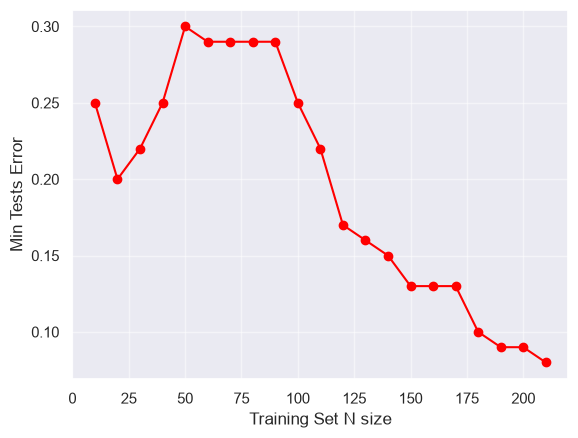

In [14]:
train_0 = train_df[train_df['class']==0]
train_0 = train_0.reset_index(drop=True)
train_1 = train_df[train_df['class']==1]
train_1 = train_1.reset_index(drop=True)

N_train_set = np.arange(10,211,10)
min_test_errors = []

for N in N_train_set:
    N_0 = N//3
    N_1 = N - N_0
    K_N = np.arange(1,N,5)
    test_errors_N = []

    X_sub_set = pd.concat([train_0.iloc[:N_0], train_1.iloc[:N_1]])
    y_sub_set = X_sub_set['class']
    X_sub_set = X_sub_set.drop(columns=['class'])

    for k in K_N:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_sub_set, y_sub_set)
        test_err = 1 - knn.score(X_test, y_test)
        test_errors_N.append(test_err)
    min_test_errors.append(min(test_errors_N))

plt.plot(N_train_set, min_test_errors,color='red', marker='o')
plt.xlabel('Training Set N size')
plt.ylabel('Min Tests Error')
plt.show()





### (d) Other Metrics
Test KNN with different metrics.

#### i. Minkowski Distance.

In [15]:
# Function for running KNN with different metric specification
k_values = np.arange(1,197,5)
def knn_minkow(X_train, y_train, X_test, y_test, metric_name, p):
    test_errors = []
    train_errors = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric_name, p=p)
        knn.fit(X_train, y_train)
        train_err = 1 - knn.score(X_train, y_train)
        train_errors.append(train_err)
        test_err = 1 - knn.score(X_test, y_test)
        test_errors.append(test_err)

    min_err = min(test_errors)
    k_stars = []
    for i, k_val in enumerate(k_values):
        if test_errors[i] == min_err:
            k_stars.append(int(k_val))

    return k_stars, min_err


##### A. Manhattan Distance with p = 1.

In [16]:
k_stars_manhattan, test_err_manhattan = knn_minkow(X_train, y_train, X_test, y_test, metric_name='manhattan', p=1)
print(f"Best k values: {k_stars_manhattan} with Test Error:{test_err_manhattan}")
print("We choose as k* = " , k_stars_manhattan[0])

Best k values: [6, 11, 26] with Test Error:0.10999999999999999
We choose as k* =  6


##### B. With log10(p) in {0.1, 0.2, 0.3, ... ,1}.

In [17]:
k_star = k_stars_manhattan[0]
log_p_values = np.arange(0.1, 1.1, 0.1)
minkow_test_errors = []

for log_p in log_p_values:
    p = 10**log_p
    knn = KNeighborsClassifier(n_neighbors=k_star, metric='minkowski', p=p)
    knn.fit(X_train, y_train)
    test_err = 1 - knn.score(X_test, y_test)
    minkow_test_errors.append(test_err)
    print(f"log10(p) = {log_p:.1f} (p = {p:.3f}) with Test Error: {test_err}")
min_err_minkow = min(minkow_test_errors)
best_p = log_p_values[np.argmin(minkow_test_errors)]
print(f"\nBest log10(p) = {best_p:.1f} with Test Error: {min_err_minkow}")

log10(p) = 0.1 (p = 1.259) with Test Error: 0.08999999999999997
log10(p) = 0.2 (p = 1.585) with Test Error: 0.08999999999999997
log10(p) = 0.3 (p = 1.995) with Test Error: 0.07999999999999996
log10(p) = 0.4 (p = 2.512) with Test Error: 0.07999999999999996
log10(p) = 0.5 (p = 3.162) with Test Error: 0.07999999999999996
log10(p) = 0.6 (p = 3.981) with Test Error: 0.06000000000000005
log10(p) = 0.7 (p = 5.012) with Test Error: 0.06999999999999995
log10(p) = 0.8 (p = 6.310) with Test Error: 0.07999999999999996
log10(p) = 0.9 (p = 7.943) with Test Error: 0.08999999999999997
log10(p) = 1.0 (p = 10.000) with Test Error: 0.08999999999999997

Best log10(p) = 0.6 with Test Error: 0.06000000000000005


##### C. Chebyshev Distance With p -> infinity.

In [18]:
k_stars_chebyshev, test_err_chebyshev = knn_minkow(X_train, y_train, X_test, y_test, metric_name='chebyshev', p=np.inf)
print(f"Best k values: {k_stars_chebyshev} with Test Error:{test_err_chebyshev}")
print("We choose as k* = " , k_stars_chebyshev[0])

Best k values: [16] with Test Error:0.07999999999999996
We choose as k* =  16


#### ii. Mahalanobis Distance.

In [19]:
cov_matrix = X_train.cov()
INV_cov_matrix = np.linalg.inv(cov_matrix)
mahalanobis_test_errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='mahalanobis', metric_params={'VI': INV_cov_matrix}, algorithm='brute')
    knn.fit(X_train, y_train)
    test_err = 1 - knn.score(X_test, y_test)
    mahalanobis_test_errors.append(test_err)

min_err_mahalanobis = min(mahalanobis_test_errors)
k_stars_mahalanobis =  k_values[np.argmin(mahalanobis_test_errors)]

print(f"Best k values: {k_stars_mahalanobis} with Test Error:{min_err_mahalanobis}")



Best k values: 1 with Test Error:0.17000000000000004


In [20]:
results = [
    {"Metric": "Manhattan", "Best k*": k_stars_manhattan[0], "Test Error": test_err_manhattan},
    {"Metric": f"Minkowski (log10(p)={best_p:.1f})", "Best k*": k_star, "Test Error": min_err_minkow},
    {"Metric": "Chebyshev", "Best k*": k_stars_chebyshev[0], "Test Error": test_err_chebyshev},
    {"Metric": "Mahalanobis", "Best k*": k_stars_mahalanobis, "Test Error": min_err_mahalanobis}
]

# 2. Create and print the table
summary_table = pd.DataFrame(results)
print(summary_table.to_string(index=False))

                  Metric  Best k*  Test Error
               Manhattan        6        0.11
Minkowski (log10(p)=0.6)        6        0.06
               Chebyshev       16        0.08
             Mahalanobis        1        0.17


### (e) Weighted Decision

In [21]:
k_values = np.arange(1,197,5)
def knn_weighted(X_train, y_train, X_test, y_test, metric_name):
    test_erros = []
    train_erros = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric_name, weights='distance')
        knn.fit(X_train, y_train)
        test_err = 1 - knn.score(X_test, y_test)
        test_erros.append(test_err)
    min_err = min(test_erros)
    k_star = k_values[np.argmin(test_erros)]
    return k_star, min_err,

k_euclidean, test_err_euclidean = knn_weighted(X_train, y_train, X_test, y_test, metric_name='euclidean')
print(f"Euclidean: best k value: {k_euclidean} with Test Error: {test_err_euclidean}")
k_manhattan, test_err_manhattan = knn_weighted(X_train, y_train, X_test, y_test, metric_name='manhattan')
print(f"Manhattan: best k value: {k_manhattan} with Test Error: {test_err_manhattan}")
k_chebyshev, test_err_chebyshev = knn_weighted(X_train, y_train, X_test, y_test, metric_name='chebyshev')
print(f"Chebyshev: best k value: {k_chebyshev} with Test Error: {test_err_chebyshev}")


Euclidean: best k value: 6 with Test Error: 0.09999999999999998
Manhattan: best k value: 26 with Test Error: 0.09999999999999998
Chebyshev: best k value: 16 with Test Error: 0.10999999999999999


### (f) Training Error Rate

The lowest training error rate achieved in this homework was 0.0. We observed this several times (for example, in the Euclidean  when $k=1$). However, this is not due to the good performance of the model; rather, it was coused by $k=1$, since in this case each training point is its own nearest neighbor. With $K=1$, the model simply uses the point's own label to predict its class, resulting in a perfect but useless model.

### References
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

https://scikit-learn.org/stable/api/sklearn.metrics.html

https://www.geeksforgeeks.org/maths/minskowski-distance/